In [ ]:
import pandas as pd

df = pd.read_csv("/content/youtube_ad_revenue_dataset.csv")

df.head(5)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [ ]:
num_cols = ['likes', 'comments', 'watch_time_minutes']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum()

,0
video_id,0
date,0
views,0
likes,0
comments,0
watch_time_minutes,0
video_length_minutes,0
subscribers,0
category,0
device,0


In [ ]:
import pandas as pd

df = pd.read_csv("/content/youtube_ad_revenue_dataset.csv")

# Check for duplicate rows across all columns
duplicate_rows = df[df.duplicated()]

print(f"Number of duplicate rows found: {len(duplicate_rows)}")

if not duplicate_rows.empty:
    print("Here are the first 5 duplicate rows:")
    display(duplicate_rows.head())
else:
    print("No duplicate rows found in the DataFrame.")

Number of duplicate rows found: 2400
Here are the first 5 duplicate rows:


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
3179,vid_4608,2025-01-11 10:50:40.993199,9945,1458.0,121.0,31645.774111,15.206639,224801,Tech,Desktop,CA,228.151319
3231,vid_3134,2025-06-05 10:50:40.993199,10077,701.0,202.0,40120.596261,12.656050,580825,Tech,TV,UK,257.175292
3666,vid_25,2024-09-18 10:50:40.993199,9947,1802.0,347.0,55506.461433,5.456635,385325,Tech,Tablet,DE,350.450592
4710,vid_4926,2024-10-24 10:50:40.993199,9995,1286.0,292.0,34484.070853,4.757113,606881,Education,TV,DE,241.775903
4818,vid_4966,2025-02-10 10:50:40.993199,10034,776.0,447.0,34912.309423,2.488627,46916,Entertainment,Mobile,DE,237.896544


In [ ]:
import pandas as pd

df = pd.read_csv("/content/youtube_ad_revenue_dataset.csv")

# Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Verify that duplicates are gone
print(f"Number of rows after removing duplicates: {len(df_cleaned)}")
print(f"Number of duplicate rows remaining (should be 0): {df_cleaned.duplicated().sum()}")

# Update the original DataFrame if desired, or proceed with df_cleaned
df = df_cleaned.copy()

display(df.head())

Number of rows after removing duplicates: 120000
Number of duplicate rows remaining (should be 0): 0


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [ ]:
df.to_csv('youtube_ad_revenue_cleaned.csv', index=False)
print("DataFrame exported to 'youtube_ad_revenue_cleaned.csv'")

DataFrame exported to 'youtube_ad_revenue_cleaned.csv'


In [ ]:
if 'duplicate_rows' in locals() and not duplicate_rows.empty:
    duplicate_rows.to_csv('youtube_ad_revenue_duplicates.csv', index=False)
    print("Duplicate rows exported to 'youtube_ad_revenue_duplicates.csv'")
else:
    print("No duplicate rows found or 'duplicate_rows' DataFrame is empty.")

Duplicate rows exported to 'youtube_ad_revenue_duplicates.csv'


In [ ]:
# Load the cleaned dataset to ensure we are working with the de-duplicated data
df = pd.read_csv('youtube_ad_revenue_cleaned.csv')

# Re-apply median imputation for missing values in specified columns
num_cols = ['likes', 'comments', 'watch_time_minutes']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify that missing values have been handled
df.isnull().sum()

,0
video_id,0
date,0
views,0
likes,0
comments,0
watch_time_minutes,0
video_length_minutes,0
subscribers,0
category,0
device,0


In [ ]:
df.to_csv('youtube_ad_revenue_cleaned_afterisnull.csv', index=False)
print("DataFrame exported to 'youtube_ad_revenue_cleaned_afterisnull.csv")

DataFrame exported to 'youtube_ad_revenue_cleaned_afterisnull.csv


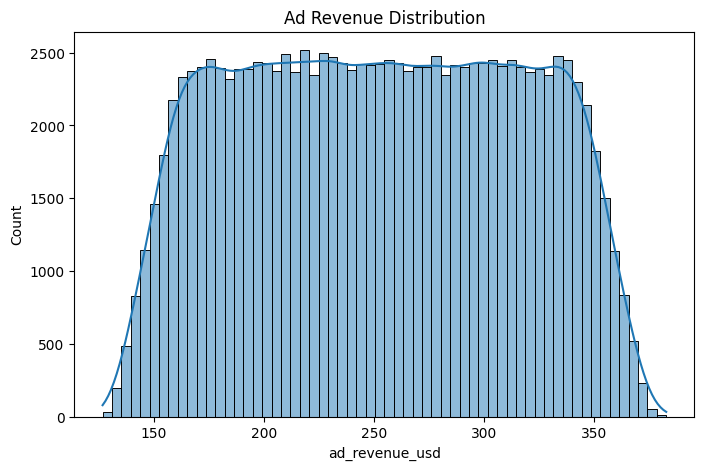

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['ad_revenue_usd'], kde=True)
plt.title("Ad Revenue Distribution")
plt.show()

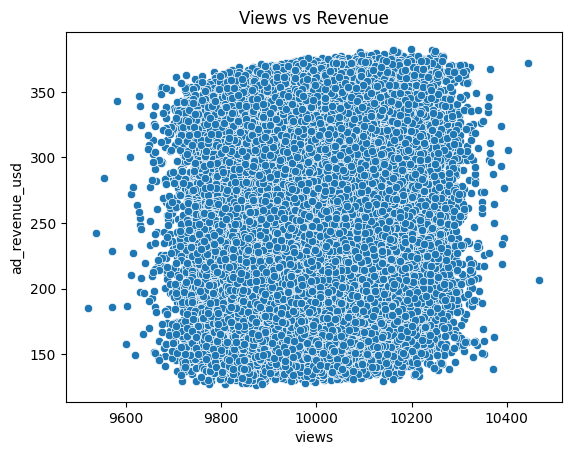

In [ ]:
sns.scatterplot(x=df['views'], y=df['ad_revenue_usd'])
plt.title("Views vs Revenue")
plt.show()

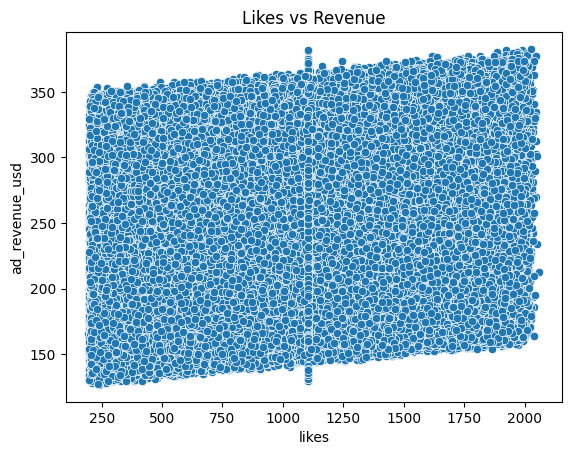

In [ ]:
sns.scatterplot(x=df['likes'], y=df['ad_revenue_usd'])
plt.title("Likes vs Revenue")
plt.show()

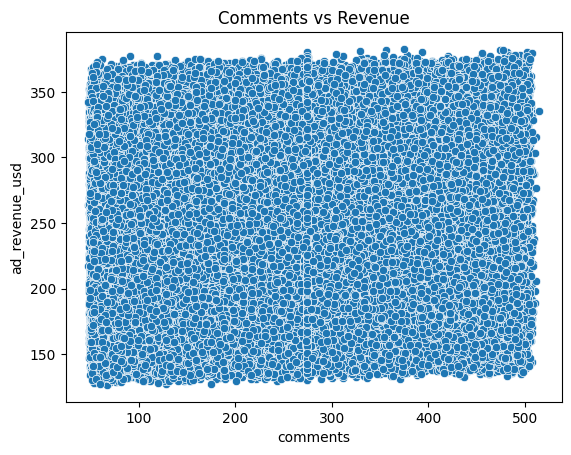

In [ ]:
sns.scatterplot(x=df['comments'], y=df['ad_revenue_usd'])
plt.title("Comments vs Revenue")
plt.show()

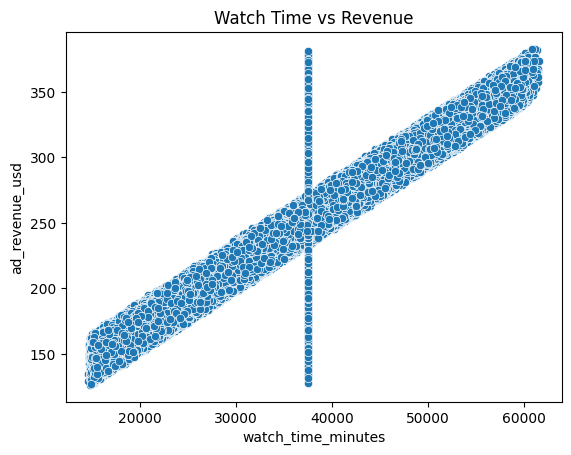

In [ ]:
sns.scatterplot(x=df['watch_time_minutes'], y=df['ad_revenue_usd'])
plt.title("Watch Time vs Revenue")
plt.show()

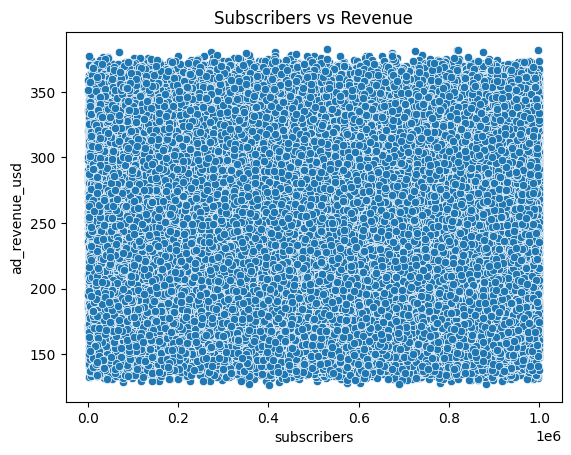

In [ ]:
sns.scatterplot(x=df['subscribers'], y=df['ad_revenue_usd'])
plt.title("Subscribers vs Revenue")
plt.show()

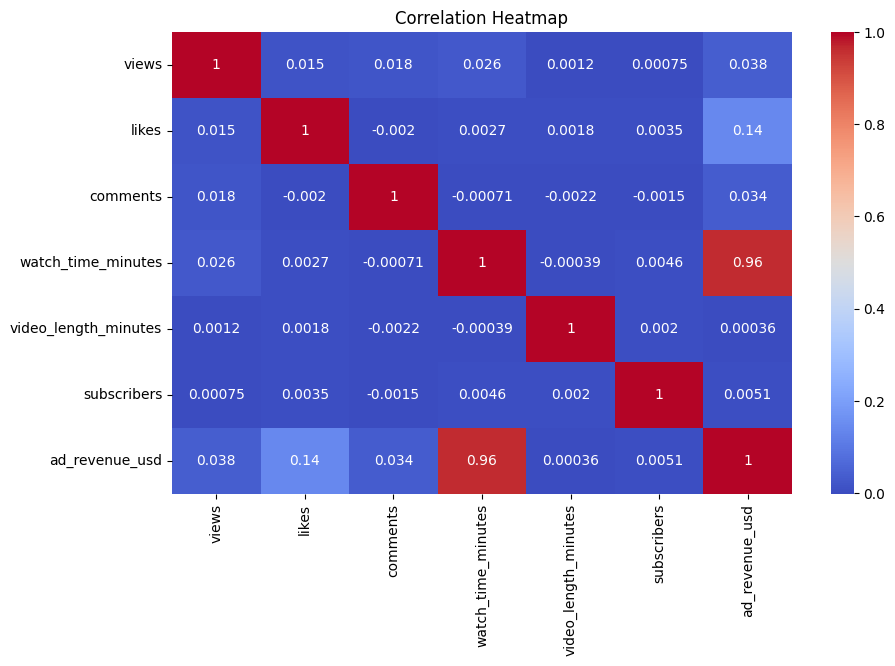

In [ ]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

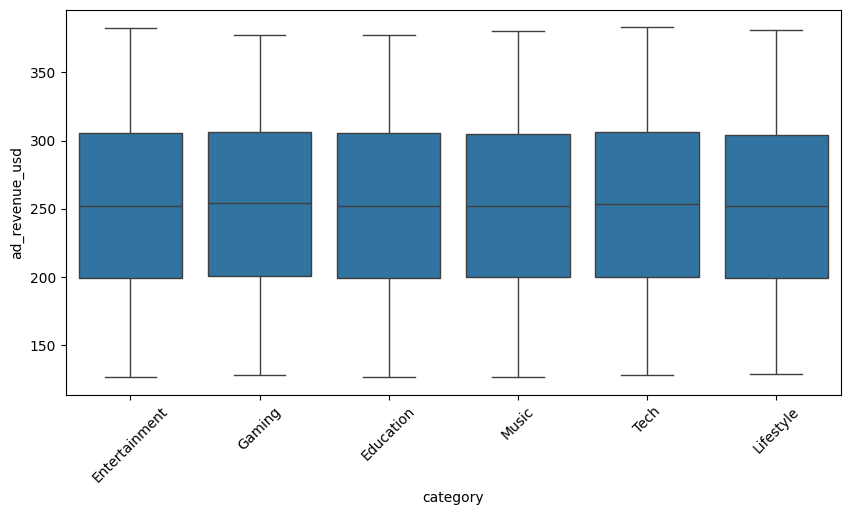

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='category', y='ad_revenue_usd', data=df)
plt.xticks(rotation=45)
plt.show()

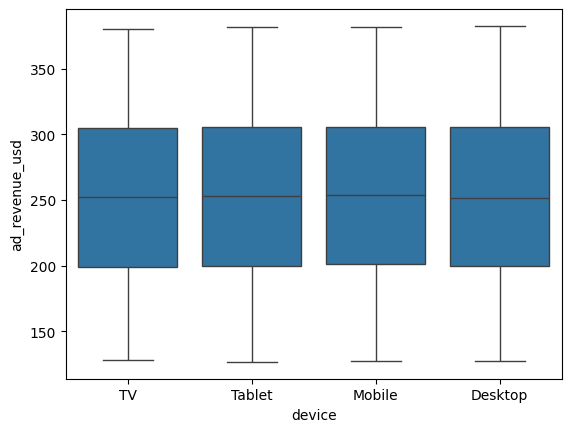

In [ ]:
sns.boxplot(x='device', y='ad_revenue_usd', data=df)
plt.show()

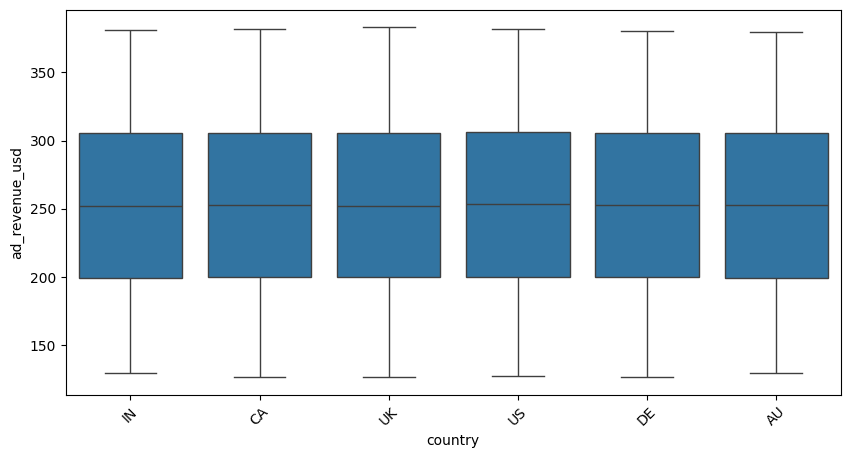

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='country', y='ad_revenue_usd', data=df)
plt.xticks(rotation=45)
plt.show()

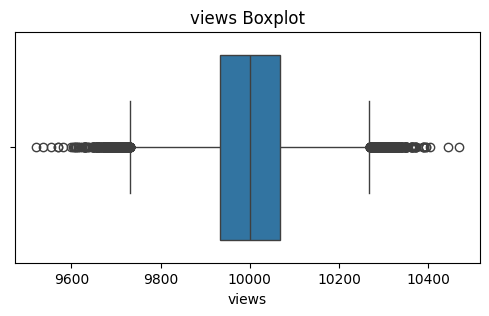

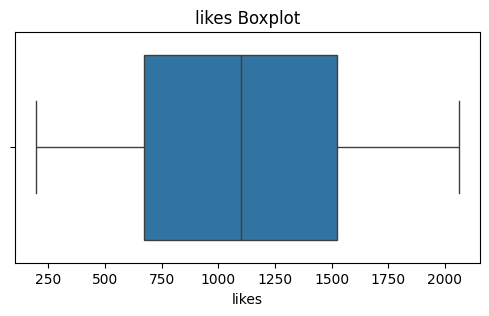

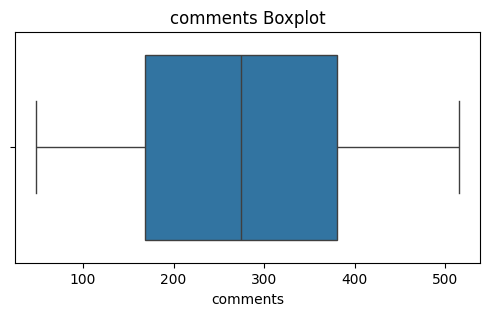

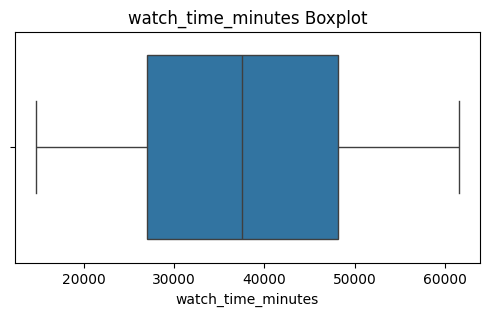

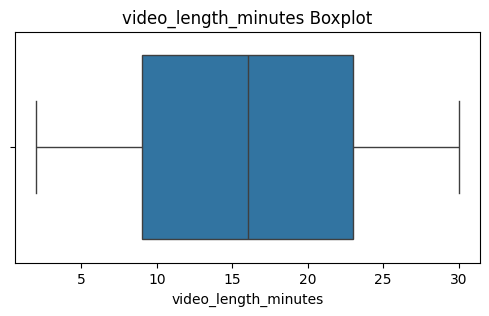

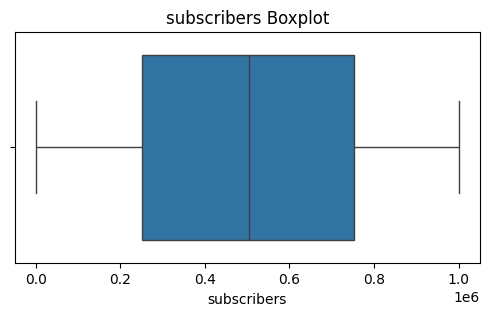

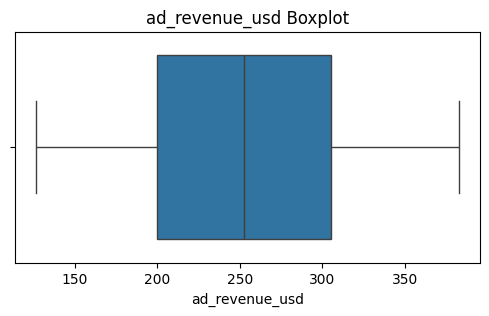

In [ ]:
num_cols = ['views', 'likes', 'comments', 'watch_time_minutes',
            'video_length_minutes', 'subscribers', 'ad_revenue_usd']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

In [ ]:
# ==========================================
# CONTENT MONETIZATION - COMPLETE PIPELINE
# ==========================================

# ------------------------------
# 1. Import Libraries
# ------------------------------
import pandas as pd
import numpy as np
import pickle


# ------------------------------
# 2. Load Dataset
# ------------------------------
df = pd.read_csv("youtube_ad_revenue_cleaned_afterisnull.csv")

print("Dataset Loaded ✅")
print("Shape:", df.shape)

# ------------------------------
# 3. Feature Engineering
# ------------------------------

# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Time features
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

# Engagement features
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']
df['like_rate'] = df['likes'] / df['views']
df['comment_rate'] = df['comments'] / df['views']

# Watch behavior
df['watch_time_per_view'] = df['watch_time_minutes'] / df['views']
df['watch_efficiency'] = df['watch_time_minutes'] / df['video_length_minutes']

# Subscriber interaction
df['subs_engagement'] = df['views'] / df['subscribers']

# Handle inf/NaN
cols = [
    'engagement_rate','like_rate','comment_rate',
    'watch_time_per_view','watch_efficiency','subs_engagement'
]

for col in cols:
    df[col].replace([np.inf, -np.inf], 0, inplace=True)
    df[col].fillna(0, inplace=True)

# Drop unnecessary columns
df.drop(['video_id','date'], axis=1, inplace=False, errors='ignore')

print("Feature Engineering Completed ✅")

# ------------------------------
# 4. Encoding
# ------------------------------
df = pd.get_dummies(df, columns=['category','device','country'], drop_first=True)

print("Encoding Completed ✅")
print("Shape after encoding:", df.shape)



Dataset Loaded ✅
Shape: (120000, 12)
Feature Engineering Completed ✅
Encoding Completed ✅
Shape after encoding: (120000, 31)


/tmp/ipykernel_15791/1141509841.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace([np.inf, -np.inf], 0, inplace=True)
/tmp/ipykernel_15791/1141509841.py:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [ ]:
df.to_csv('Encoding.csv', index=False)
print("DataFrame exported to 'Encoding.csv'")

DataFrame exported to 'Encoding.csv'


In [ ]:
import pickle

feature_columns = X.columns.tolist()

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("feature_columns.pkl saved ✅")

feature_columns.pkl saved ✅


In [ ]:
# ==========================================
# FINAL MODEL BUILDING + SAVING PIPELINE
# ==========================================

import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
df = pd.read_csv("Encoding.csv")

# ------------------------------------------
# 2. Define Features & Target
# ------------------------------------------
X = df.drop(['ad_revenue_usd', 'video_id', 'date'], axis=1)
y = df['ad_revenue_usd']

# ------------------------------------------
# 3. Train-Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------
# 4. Scaling
# ------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------
# 5. Models
# ------------------------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# ------------------------------------------
# 6. Train & Evaluate
# ------------------------------------------
results = []

for name, model in models.items():

    if name in ["Linear Regression", "Ridge", "Lasso"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append([name, r2, rmse, mae])

# Results table
results_df = pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MAE"])
results_df = results_df.sort_values(by="R2", ascending=False)

print("\n📊 Model Comparison:")
print(results_df)

# ------------------------------------------
# 7. Select Best Model
# ------------------------------------------
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print("\n🏆 Best Model:", best_model_name)

# Train again
if best_model_name in ["Linear Regression", "Ridge", "Lasso"]:
    best_model.fit(X_train_scaled, y_train)
else:
    best_model.fit(X_train, y_train)

# ------------------------------------------
# 8. Test Prediction
# ------------------------------------------
if best_model_name in ["Linear Regression", "Ridge", "Lasso"]:
    sample_pred = best_model.predict(X_test_scaled[0:1])
else:
    sample_pred = best_model.predict(X_test.iloc[0:1])

print("\n🔍 Sample Prediction:", sample_pred[0])
print("Actual Value:", y_test.iloc[0])

# ------------------------------------------
# 9. SAVE EVERYTHING (CRITICAL)
# ------------------------------------------
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("\n✅ Model, Scaler, Columns saved successfully!")


📊 Model Comparison:
               Model        R2       RMSE       MAE
1              Ridge  0.952575  13.479830  3.118654
0  Linear Regression  0.952575  13.479862  3.118106
2              Lasso  0.951900  13.575432  4.142937
4      Random Forest  0.949946  13.848433  3.565804
3      Decision Tree  0.898920  19.679577  5.373589

🏆 Best Model: Ridge

🔍 Sample Prediction: 352.8853827392491
Actual Value: 352.8535207166556

✅ Model, Scaler, Columns saved successfully!


In [1]:
%%writefile app.py

# ==========================================
# FINAL STREAMLIT APP - NO ERRORS
# ==========================================

# Install Streamlit if not already installed
try:
    import streamlit as st
except ImportError:
 import streamlit as st
import pandas as pd
import numpy as np
import pickle

# ------------------------------------------
# 1. App Config (MUST BE FIRST)
# ------------------------------------------
st.set_page_config(page_title="YouTube Revenue Predictor", layout="wide")

# ------------------------------------------
# 2. Add YouTube Background Logic
# ------------------------------------------
def add_bg_from_url():
    st.markdown(
         f"""
         <style>
         .stApp {{
             background-image: url("https://upload.wikimedia.org/wikipedia/commons/e/ef/Youtube_logo.png");
             background-attachment: fixed;
             background-size: 300px; /* Controls the width of the logo */
             background-repeat: no-repeat;
             background-position: center;
             background-color: rgba(120, 120, 120, 0.95); /* Optional: slight overlay for readability */
         }}

         /* This ensures your content blocks stay readable over the background */
         .stMarkdown, .stDataFrame, .stTable, .stButton {{
             background-color: rgba(120, 120, 120, 0.8);
             padding: 10px;
             border-radius: 10px;
         }}
         </style>
         """,
         unsafe_allow_html=True
     )

add_bg_from_url()

# ------------------------------------------
# 3. Load Files
# ------------------------------------------
# Wrap in try-except to prevent crash if files are missing
try:
    with open("best_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    with open("feature_columns.pkl", "rb") as f:
        feature_columns = pickle.load(f)
except FileNotFoundError:
    st.error("Model files not found. Please ensure .pkl files are in the directory.")
    st.stop()

# ------------------------------------------
# 4. App Content
# ------------------------------------------
st.title("📊 YouTube Ad Revenue Prediction")

# ------------------------------------------
# Sidebar Inputs
# ------------------------------------------
st.sidebar.header("📥 Enter Video Details")

views = st.sidebar.number_input("Views", value=10000)
likes = st.sidebar.number_input("Likes", value=1000)
comments = st.sidebar.number_input("Comments", value=200)
watch_time = st.sidebar.number_input("Watch Time (minutes)", value=30000)
video_length = st.sidebar.number_input("Video Length (minutes)", value=10)
subscribers = st.sidebar.number_input("Subscribers", value=500000)

# Dropdowns (must match training categories)
category = st.sidebar.selectbox("Category", ["Music", "Gaming", "Tech", "Entertainment", "Lifestyle"])
device = st.sidebar.selectbox("Device", ["Mobile", "Tablet", "TV"])
country = st.sidebar.selectbox("Country", ["US", "IN", "UK", "CA", "DE"])

# ------------------------------------------
# Feature Engineering
# ------------------------------------------
engagement_rate = (likes + comments) / views if views != 0 else 0
like_rate = likes / views if views != 0 else 0
comment_rate = comments / views if views != 0 else 0
watch_time_per_view = watch_time / views if views != 0 else 0
watch_efficiency = watch_time / video_length if video_length != 0 else 0
subs_engagement = views / subscribers if subscribers != 0 else 0

# ------------------------------------------
# Create Input DataFrame (MATCH TRAINING)
# ------------------------------------------
input_df = pd.DataFrame(columns=feature_columns)
input_df.loc[0] = 0

# Fill numerical features
input_df['views'] = views
input_df['likes'] = likes
input_df['comments'] = comments
input_df['watch_time_minutes'] = watch_time
input_df['video_length_minutes'] = video_length
input_df['subscribers'] = subscribers

# Engineered features
input_df['engagement_rate'] = engagement_rate
input_df['like_rate'] = like_rate
input_df['comment_rate'] = comment_rate
input_df['watch_time_per_view'] = watch_time_per_view
input_df['watch_efficiency'] = watch_efficiency
input_df['subs_engagement'] = subs_engagement

# ------------------------------------------
# Apply Encoding (Dynamic)
# ------------------------------------------
cat_col = f"category_{category}"
dev_col = f"device_{device}"
country_col = f"country_{country}"

if cat_col in input_df.columns:
    input_df[cat_col] = 1

if dev_col in input_df.columns:
    input_df[dev_col] = 1

if country_col in input_df.columns:
    input_df[country_col] = 1

# ------------------------------------------
# Scaling
# ------------------------------------------
input_scaled = scaler.transform(input_df)

# ------------------------------------------
# Prediction
# ------------------------------------------
if st.sidebar.button("Predict Revenue"):

    prediction = model.predict(input_scaled)

    st.subheader("💰 Predicted Revenue")
    st.success(f"${prediction[0]:.2f}")

# ------------------------------------------
# Debug Section (Optional)
# ------------------------------------------
with st.expander("🔍 Debug Info"):
    st.write("Input DataFrame:", input_df)
    st.write("Scaled Input:", input_scaled)


Writing app.py
